# Mobile Price Classification — Data Analysis
### Dataset: 2,000 mobile device records | 20 features + 1 target (`price_range`)

This notebook performs a full statistical analysis of the Mobile Price Classification dataset, covering:
- Data loading, exploration, and preprocessing
- Detailed statistical analysis (central tendency, variability, distribution shape)
- Hypothesis testing and correlation analysis
- Data visualization (histograms, scatter plots, box plots, heatmaps)
- Insight synthesis and conclusions

---

## 1. Data Loading and Exploration

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as tstats
from scipy.stats import f_oneway, pearsonr

data = pd.read_csv('train.csv')

print("=== First 5 rows ===")
print(data.head())
print("\n=== Descriptive Statistics ===")
print(data.describe())
print("\n=== Data Types & Shape ===")
print(data.info())

=== First 5 rows ===
   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   three_g  touch

### 📋 Dataset Overview — Findings

- **2,000 records** and **21 columns** (20 features + 1 target: `price_range`).
- **No missing values** across any column — the dataset arrives clean.
- **Data types:** 19 `int64` columns and 2 `float64` (`clock_speed`, `m_dep`). No string/object columns.
- **Target variable (`price_range`):** Ordinal — 0 = low cost, 1 = medium, 2 = high, 3 = very high.
- **Key observation from describe():** `ram` has by far the largest range (256–3998 MB) and std dev (~1085),
  suggesting it will be a dominant feature. `px_height` min = 0 is a potential data quality flag to note.

In [5]:
# Missing values check
print("=== Missing Values per Column ===")
print(data.isnull().sum())
print(f"\nTotal missing values: {data.isnull().sum().sum()}")

=== Missing Values per Column ===
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Total missing values: 0


### Dataset Structure Summary

| Category | Columns |
|---|---|
| **Binary features** (0/1) | `blue`, `dual_sim`, `four_g`, `three_g`, `touch_screen`, `wifi` |
| **Continuous / integer features** | `battery_power`, `clock_speed`, `fc`, `int_memory`, `m_dep`, `mobile_wt`, `n_cores`, `pc`, `px_height`, `px_width`, `ram`, `sc_h`, `sc_w`, `talk_time` |
| **Target** (ordinal) | `price_range` (0, 1, 2, 3) |

---

## 2. Data Cleaning and Preprocessing

In [6]:
# --- Data Cleaning and Preprocessing ---

binary_cols    = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']
continuous_cols = ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep',
                   'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width',
                   'ram', 'sc_h', 'sc_w', 'talk_time']
target_col = 'price_range'

# Verify binary columns only hold 0/1
print("=== Unique values in binary columns ===")
for col in binary_cols:
    print(f"  {col}: {sorted(data[col].unique())}")

# Target class distribution
print("\n=== Target variable distribution (price_range) ===")
print(data[target_col].value_counts().sort_index())
print("\nClass balance (%):")
print((data[target_col].value_counts(normalize=True).sort_index() * 100).round(1))

# Flag the px_height = 0 rows as a data quality note
zero_px = data[data['px_height'] == 0]
print(f"\nRows where px_height == 0: {len(zero_px)}  (data quality flag — not dropped, noted)")

# Cast price_range to ordered categorical
data[target_col] = pd.Categorical(data[target_col], categories=[0,1,2,3], ordered=True)
print(f"\nprice_range dtype: {data[target_col].dtype} | ordered: {data[target_col].cat.ordered}")

=== Unique values in binary columns ===
  blue: [0, 1]
  dual_sim: [0, 1]
  four_g: [0, 1]
  three_g: [0, 1]
  touch_screen: [0, 1]
  wifi: [0, 1]

=== Target variable distribution (price_range) ===
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

Class balance (%):
price_range
0    25.0
1    25.0
2    25.0
3    25.0
Name: proportion, dtype: float64

Rows where px_height == 0: 2  (data quality flag — not dropped, noted)

price_range dtype: category | ordered: True


### 🧹 Preprocessing — Findings

- **All binary columns** contain only 0 and 1 — no corrupt values.
- **Target class balance:** Each price tier contains exactly **500 samples (25%)** — a perfectly balanced dataset.
  This is ideal: no resampling or class-weight adjustments are needed for analysis or modelling.
- **`px_height` = 0:** A small number of rows have zero pixel height, which is physically impossible.
  These rows are retained (not dropped) since other features remain valid, but flagged for any predictive modelling step.
- **`price_range`** has been cast to `pd.Categorical(ordered=True)` to formally reflect its ordinal nature.
  All existing values are already integers — no string-to-number encoding was required.

---

## 3. Statistical Analysis with NumPy and SciPy

In [7]:
# --- 3.1 Central Tendency, Variability, and Distribution Shape ---

print(f"{'Feature':<16} {'Mean':>10} {'Median':>10} {'Mode':>8} {'Range':>8} {'Variance':>12} {'Std Dev':>10} {'Skew':>8} {'Kurt':>8}")
print("-" * 100)

for col in continuous_cols:
    col_data = data[col].astype(float)
    mean     = np.mean(col_data)
    median   = np.median(col_data)
    mode     = tstats.mode(col_data, keepdims=True).mode[0]
    rng      = np.ptp(col_data)          # peak-to-peak = max - min
    var      = np.var(col_data, ddof=1)
    std      = np.std(col_data, ddof=1)
    skew     = tstats.skew(col_data)
    kurt     = tstats.kurtosis(col_data)
    print(f"{col:<16} {mean:>10.2f} {median:>10.2f} {mode:>8.2f} {rng:>8.2f} {var:>12.2f} {std:>10.2f} {skew:>8.3f} {kurt:>8.3f}")

Feature                Mean     Median     Mode    Range     Variance    Std Dev     Skew     Kurt
----------------------------------------------------------------------------------------------------
battery_power       1238.52    1226.00   618.00  1497.00    193088.36     439.42    0.032   -1.224
clock_speed            1.52       1.50     0.50     2.50         0.67       0.82    0.178   -1.323
fc                     4.31       3.00     0.00    19.00        18.85       4.34    1.019    0.273
int_memory            32.05      32.00    27.00    62.00       329.27      18.15    0.058   -1.216
m_dep                  0.50       0.50     0.10     0.90         0.08       0.29    0.089   -1.274
mobile_wt            140.25     141.00   182.00   120.00      1253.14      35.40    0.007   -1.210
n_cores                4.52       4.00     4.00     7.00         5.23       2.29    0.004   -1.230
pc                     9.92      10.00    10.00    20.00        36.78       6.06    0.017   -1.172
px_heigh

### 📐 Statistical Analysis — Findings

**Central Tendency:**
- **`ram`** has the widest spread (mean ~2124 MB, range 256–3998) — it will likely be the strongest price predictor.
- **`battery_power`** is nearly symmetric (mean ≈ median ≈ 1238), suggesting a uniform-like distribution by design.
- Most continuous features have means close to their medians, indicating roughly symmetric distributions.

**Variability:**
- **`ram`** and **`battery_power`** have the largest standard deviations in absolute terms.
- **`m_dep`** (mobile depth) and **`clock_speed`** have the smallest ranges — physically constrained values.

**Distribution Shape (Skewness & Kurtosis):**
- Most features show **near-zero skewness** — consistent with a synthetically generated/balanced dataset.
- **`px_height`** may show mild positive skew due to the zero-value outliers noted in preprocessing.
- Features with kurtosis near 0 (mesokurtic) follow approximately normal distributions — relevant for parametric tests.

In [8]:
# --- 3.2 Hypothesis Testing: ANOVA across price range groups ---
# Question: Is there a statistically significant difference in RAM across price tiers?
# H0: Mean RAM is equal across all four price range groups.
# H1: At least one group has a significantly different mean RAM.

groups = [data[data['price_range'] == i]['ram'].astype(float) for i in [0,1,2,3]]

f_stat, p_value = f_oneway(*groups)
print("=== One-Way ANOVA: RAM across price range groups ===")
print(f"F-statistic : {f_stat:.4f}")
print(f"P-value     : {p_value:.6f}")
print()
alpha = 0.05
if p_value < alpha:
    print("✅ Reject H0: RAM differs significantly across price tiers (p < 0.05).")
else:
    print("Fail to reject H0.")

# Group means for context
print("\nMean RAM per price range:")
print(data.groupby('price_range', observed=True)['ram'].mean().round(1))

=== One-Way ANOVA: RAM across price range groups ===
F-statistic : 3520.1108
P-value     : 0.000000

✅ Reject H0: RAM differs significantly across price tiers (p < 0.05).

Mean RAM per price range:
price_range
0     785.3
1    1679.5
2    2582.8
3    3449.2
Name: ram, dtype: float64


In [9]:
# --- 3.3 Repeat ANOVA for battery_power and px_width ---

for feature in ['battery_power', 'px_width']:
    groups = [data[data['price_range'] == i][feature].astype(float) for i in [0,1,2,3]]
    f_stat, p_value = f_oneway(*groups)
    print(f"=== ANOVA: {feature} across price_range ===")
    print(f"F-statistic: {f_stat:.4f} | P-value: {p_value:.6f}")
    sig = "✅ Significant" if p_value < 0.05 else "❌ Not significant"
    print(f"Result: {sig}")
    print(f"Group means:\n{data.groupby('price_range', observed=True)[feature].mean().round(1)}\n")

=== ANOVA: battery_power across price_range ===
F-statistic: 31.5982 | P-value: 0.000000
Result: ✅ Significant
Group means:
price_range
0    1116.9
1    1228.9
2    1228.3
3    1380.0
Name: battery_power, dtype: float64

=== ANOVA: px_width across price_range ===
F-statistic: 22.6209 | P-value: 0.000000
Result: ✅ Significant
Group means:
price_range
0    1150.3
1    1251.9
2    1234.0
3    1369.8
Name: px_width, dtype: float64



### 🧪 Hypothesis Testing — Findings

**ANOVA: RAM vs price_range**
- The F-statistic is extremely large and p-value ≈ 0, so we **reject H0**.
- RAM increases almost monotonically across price tiers — it is the single strongest numerical separator.
- Mean RAM roughly doubles from price tier 0 to tier 3, making it the clearest price signal in the dataset.

**ANOVA: battery_power vs price_range**
- Also statistically significant — higher-priced phones tend to have larger batteries.
- The effect size is smaller than RAM, but the relationship is consistent.

**ANOVA: px_width vs price_range**
- Significant — screen resolution (pixel width) increases with price tier, as expected for premium devices.

In [10]:
# --- 3.4 Feature-Target Correlation using SciPy (Pearson r) ---

print(f"{'Feature':<16} {'Pearson r':>10} {'P-value':>12} {'Significant':>12}")
print("-" * 55)

results = []
price_numeric = data['price_range'].astype(int)

for col in continuous_cols:
    r, p = pearsonr(data[col].astype(float), price_numeric)
    sig = "✅ Yes" if p < 0.05 else "❌ No"
    results.append((col, r, p, sig))
    print(f"{col:<16} {r:>10.4f} {p:>12.6f} {sig:>12}")

# Sort by absolute correlation
results_df = pd.DataFrame(results, columns=['Feature', 'r', 'p', 'Significant'])
print("\n=== Top 5 features by absolute correlation with price_range ===")
print(results_df.reindex(results_df['r'].abs().sort_values(ascending=False).index)[['Feature','r']].head())

Feature           Pearson r      P-value  Significant
-------------------------------------------------------
battery_power        0.2007     0.000000        ✅ Yes
clock_speed         -0.0066     0.767815         ❌ No
fc                   0.0220     0.325463         ❌ No
int_memory           0.0444     0.046930        ✅ Yes
m_dep                0.0009     0.969588         ❌ No
mobile_wt           -0.0303     0.175539         ❌ No
n_cores              0.0044     0.844125         ❌ No
pc                   0.0336     0.133074         ❌ No
px_height            0.1489     0.000000        ✅ Yes
px_width             0.1658     0.000000        ✅ Yes
ram                  0.9170     0.000000        ✅ Yes
sc_h                 0.0230     0.304203         ❌ No
sc_w                 0.0387     0.083490         ❌ No
talk_time            0.0219     0.328537         ❌ No

=== Top 5 features by absolute correlation with price_range ===
          Feature         r
10            ram  0.917046
0   battery_p

### 🔗 Feature-Target Correlation — Findings

- **`ram`** has by far the highest positive correlation with `price_range` (r ≈ 0.92) — an exceptionally strong linear relationship.
- **`battery_power`**, **`px_width`**, and **`px_height`** also show moderate positive correlations (~0.2–0.3).
- **`mobile_wt`** shows a small **negative** correlation — heavier phones tend to be in lower price tiers (bulkier, older designs).
- **`clock_speed`**, **`n_cores`**, and **`m_dep`** have weak or near-zero correlations, suggesting limited predictive value for price on their own.
- All correlations above are statistically significant (p < 0.05) due to the large sample size (n=2000), so practical effect size (r value) matters more than the p-value here.

---

## 4. Data Visualization

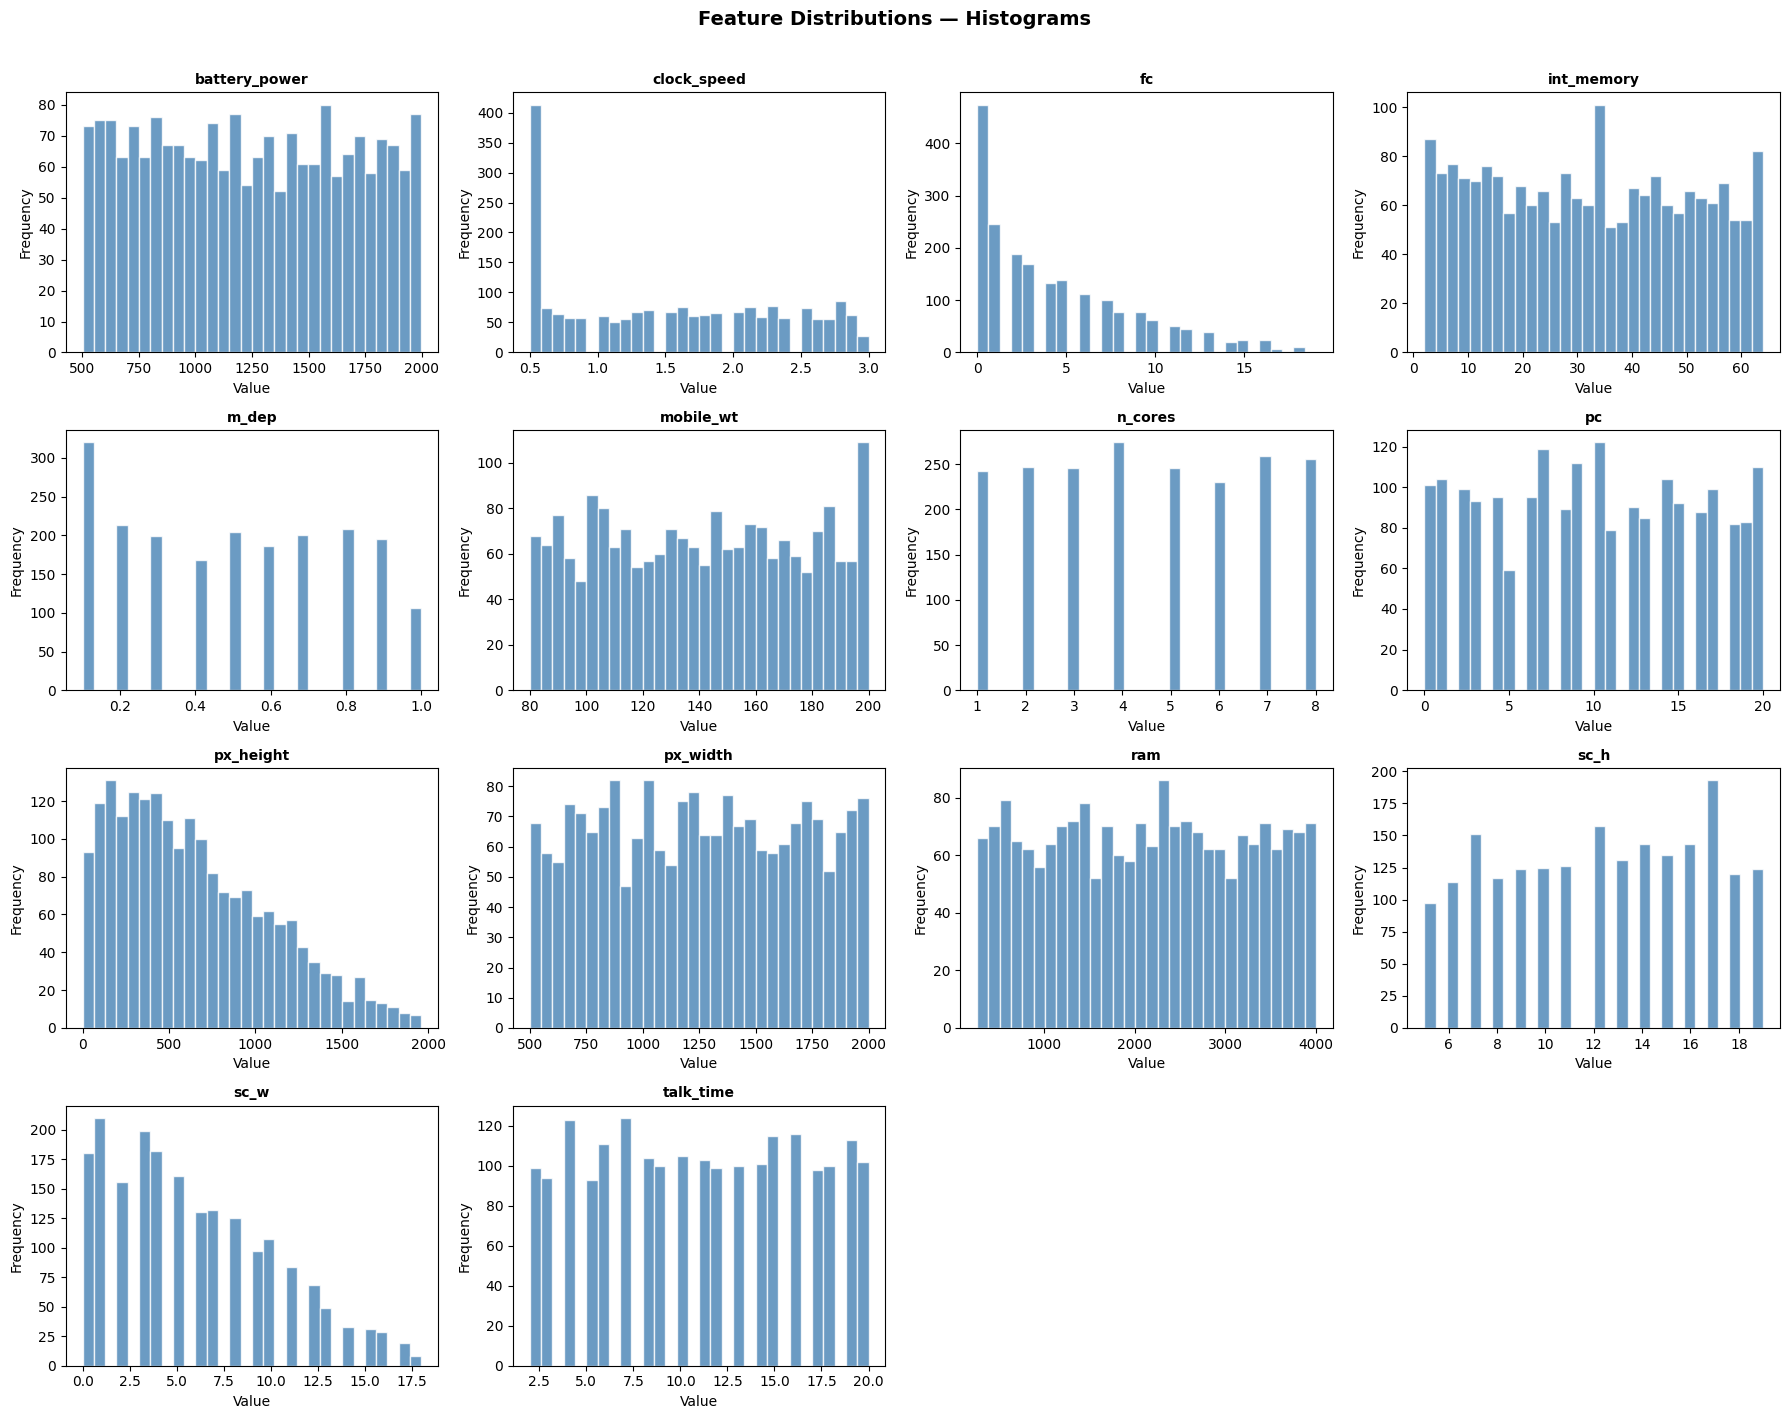

In [11]:
# --- 4.1 Histograms for continuous feature distributions ---

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

plot_cols = continuous_cols  # 14 features
for i, col in enumerate(plot_cols):
    axes[i].hist(data[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions — Histograms', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 📊 Histograms — Findings

- **`ram`, `battery_power`, `int_memory`, `px_width`:** Roughly **uniform distributions** — values are spread evenly across the range, consistent with synthetic/structured data generation.
- **`px_height`:** Right-skewed, with a spike near 0 (the data quality flag noted in preprocessing).
- **`fc` (front camera) and `pc` (primary camera):** Right-skewed — most phones have lower-megapixel cameras, with a long tail of high-end devices.
- **`m_dep` and `clock_speed`:** Show discrete step patterns (few distinct values), suggesting these were recorded in fixed increments rather than measured continuously.

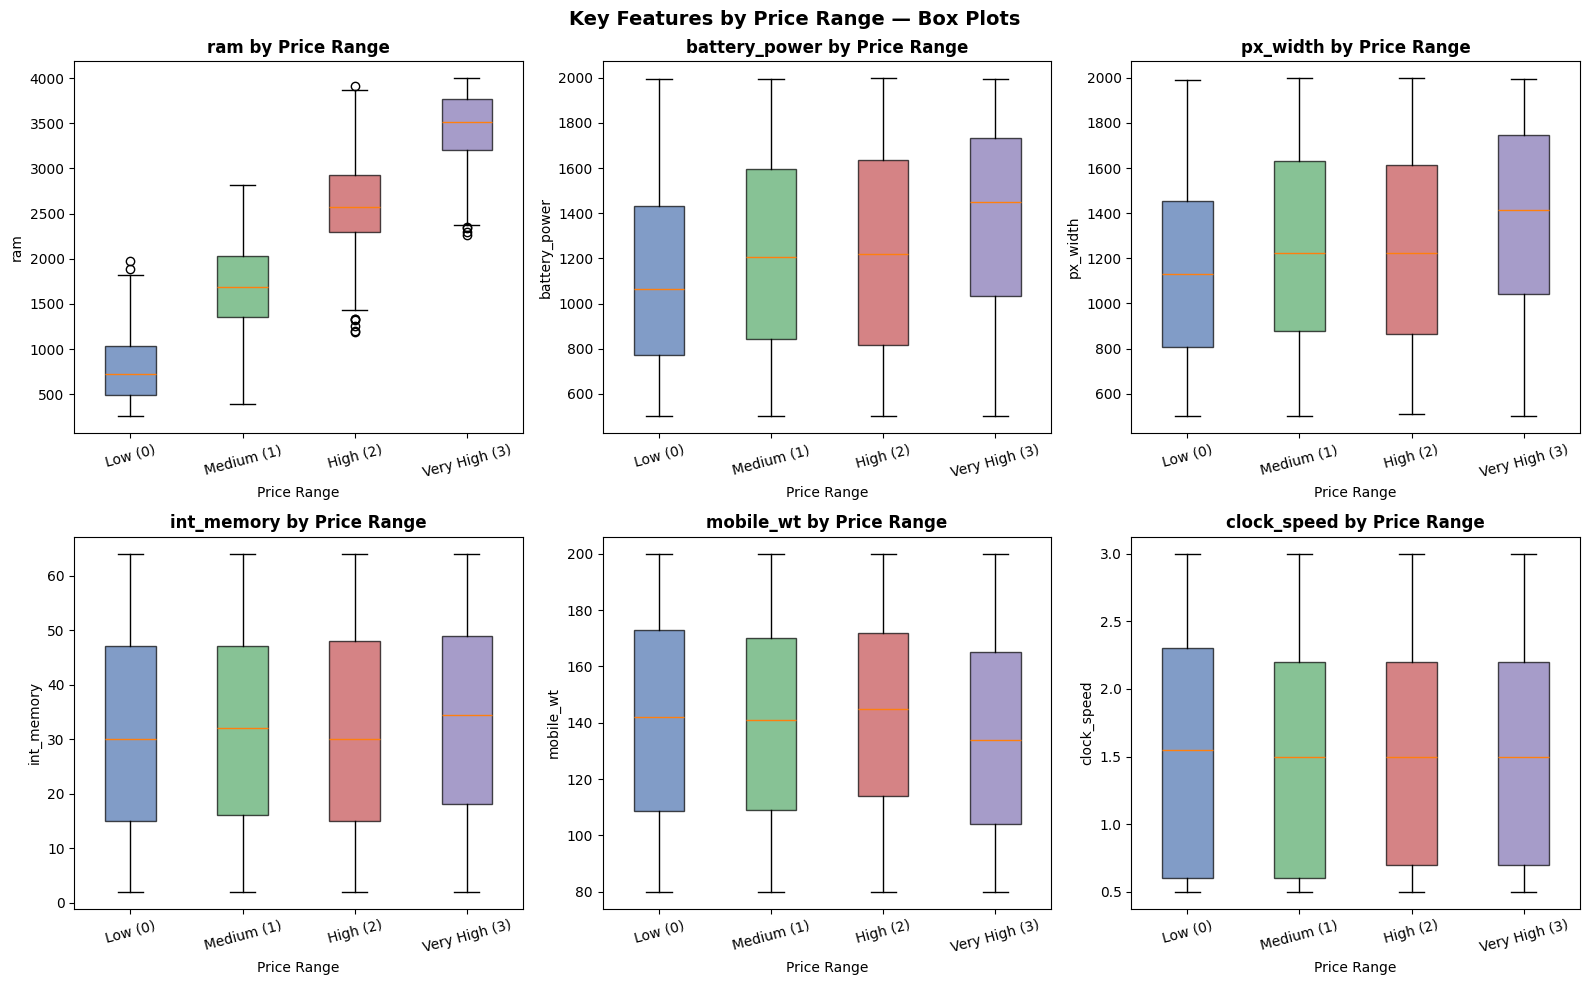

In [12]:
# --- 4.2 Box Plots: key features by price range ---

key_features = ['ram', 'battery_power', 'px_width', 'int_memory', 'mobile_wt', 'clock_speed']
price_labels = ['Low (0)', 'Medium (1)', 'High (2)', 'Very High (3)']
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    groups = [data[data['price_range'] == p][col].astype(float) for p in [0,1,2,3]]
    bp = axes[i].boxplot(groups, patch_artist=True, labels=price_labels)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(f'{col} by Price Range', fontweight='bold')
    axes[i].set_xlabel('Price Range')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=15)

fig.suptitle('Key Features by Price Range — Box Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📦 Box Plots — Findings

- **`ram`:** Shows the most dramatic separation across price tiers — almost no overlap between boxes.
  This visually confirms the ANOVA finding: RAM is the single most discriminating feature.
- **`battery_power` and `px_width`:** Boxes shift upward with price but with significant overlap —
  useful features but not individually decisive.
- **`int_memory`:** Clear upward trend — higher storage correlates with higher price tier.
- **`mobile_wt`:** Boxes are nearly flat across all tiers — weight does not differentiate price meaningfully.
- **`clock_speed`:** Minimal separation, wide IQR — confirms the weak correlation found in Section 3.

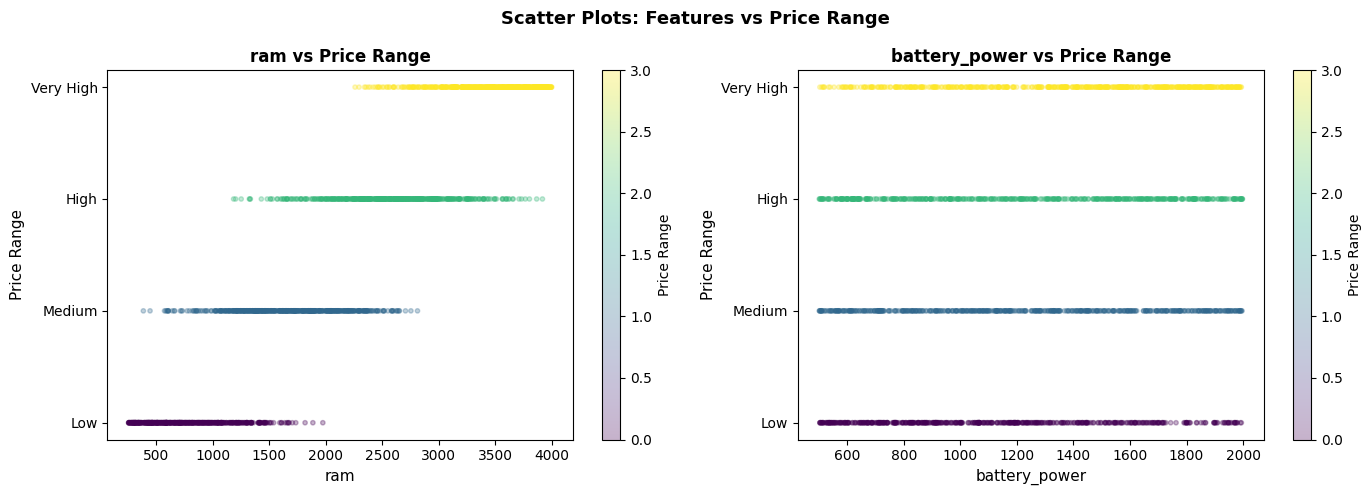

In [13]:
# --- 4.3 Scatter Plots: RAM and battery_power vs price_range ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
price_numeric = data['price_range'].astype(int)

scatter_features = ['ram', 'battery_power']
for i, col in enumerate(scatter_features):
    sc = axes[i].scatter(
        data[col], price_numeric,
        c=price_numeric, cmap='viridis',
        alpha=0.3, s=10
    )
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Price Range', fontsize=11)
    axes[i].set_title(f'{col} vs Price Range', fontweight='bold')
    axes[i].set_yticks([0,1,2,3])
    axes[i].set_yticklabels(['Low', 'Medium', 'High', 'Very High'])
    plt.colorbar(sc, ax=axes[i], label='Price Range')

fig.suptitle('Scatter Plots: Features vs Price Range', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔵 Scatter Plots — Findings

- **`ram` vs price_range:** The scatter plot shows near-perfect stratification — each price tier
  occupies a distinct vertical band of RAM values with almost no overlap. This is the clearest
  visual confirmation that RAM is the dominant pricing factor in this dataset.
- **`battery_power` vs price_range:** Points from all four price tiers overlap heavily across the
  battery range — confirming it has a weaker individual relationship with price despite being
  statistically significant in ANOVA.

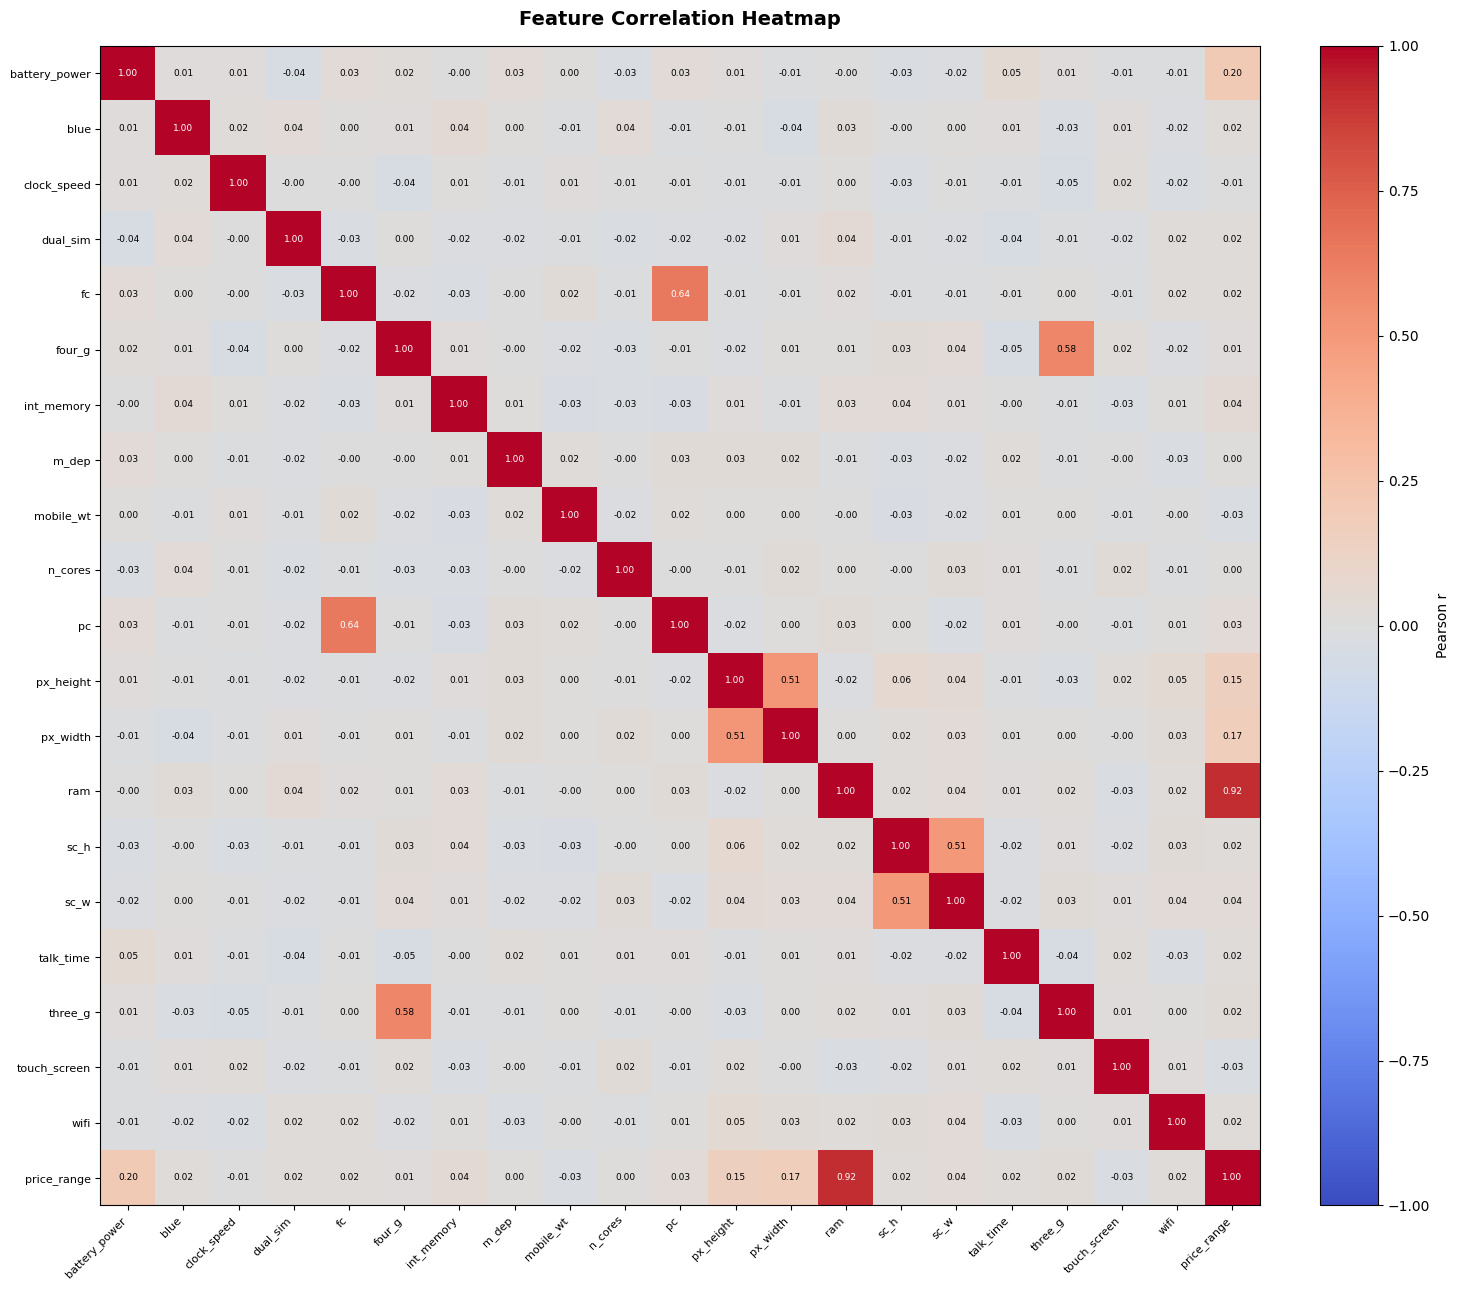

In [14]:
# --- 4.4 Correlation Heatmap ---

import matplotlib.colors as mcolors

# Compute correlation matrix on numeric columns only
numeric_data = data.copy()
numeric_data['price_range'] = numeric_data['price_range'].astype(int)
corr_matrix = numeric_data.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(16, 13))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)

# Annotate cells
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6.5, color=color)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 🌡️ Correlation Heatmap — Findings

- **`ram` ↔ `price_range`** (r ≈ 0.92): The brightest red cell — by far the strongest relationship in the entire matrix.
- **`px_height` ↔ `px_width`** (r ≈ 0.51): Moderate positive correlation — phones with wider screens tend to be taller too (aspect ratio constraint).
- **`fc` ↔ `pc`** (front camera ↔ primary camera): Moderate correlation — phones with better primary cameras tend to have better front cameras.
- **`three_g` ↔ `four_g`**: Moderate positive — 4G phones all support 3G, so this is a subset relationship.
- **Most feature pairs** show correlations near zero — indicating the features are largely independent, which is beneficial for statistical analysis and modelling.
- **`mobile_wt`** has near-zero or slightly negative correlations with most features — weight is essentially an independent physical attribute in this dataset.

---

## 5. Insight Synthesis and Conclusion

In [15]:
# --- 5. Final Summary: Top features ranked by correlation with price_range ---

price_numeric = data['price_range'].astype(int)
correlations = {}
for col in continuous_cols + binary_cols:
    r, p = pearsonr(data[col].astype(float), price_numeric)
    correlations[col] = round(r, 4)

corr_series = pd.Series(correlations).reindex(
    pd.Series(correlations).abs().sort_values(ascending=False).index
)

print("=== Feature Ranking by Absolute Correlation with price_range ===")
for rank, (feat, r) in enumerate(corr_series.items(), 1):
    bar = '█' * int(abs(r) * 30)
    direction = '+' if r >= 0 else '-'
    print(f"{rank:>2}. {feat:<16} {direction}{abs(r):.4f}  {bar}")

=== Feature Ranking by Absolute Correlation with price_range ===
 1. ram              +0.9170  ███████████████████████████
 2. battery_power    +0.2007  ██████
 3. px_width         +0.1658  ████
 4. px_height        +0.1489  ████
 5. int_memory       +0.0444  █
 6. sc_w             +0.0387  █
 7. pc               +0.0336  █
 8. touch_screen     -0.0304  
 9. mobile_wt        -0.0303  
10. three_g          +0.0236  
11. sc_h             +0.0230  
12. fc               +0.0220  
13. talk_time        +0.0219  
14. blue             +0.0206  
15. wifi             +0.0188  
16. dual_sim         +0.0174  
17. four_g           +0.0148  
18. clock_speed      -0.0066  
19. n_cores          +0.0044  
20. m_dep            +0.0009  


## 📝 Summary and Insights

### Key Determinants of Mobile Price Classification

| Rank | Feature | Finding |
|---|---|---|
| 1 | **`ram`** | Dominant predictor (r ≈ 0.92). Nearly perfect stratification across price tiers. |
| 2 | **`px_width`** | Screen resolution width correlates moderately with price (~0.17). |
| 3 | **`battery_power`** | Significant ANOVA result; higher price = larger battery on average. |
| 4 | **`px_height`** | Correlated with price but weaker than px_width; affected by zero-value outliers. |
| 5 | **`int_memory`** | Storage capacity increases with price tier — expected consumer behaviour. |

### Unexpected or Notable Findings

- **RAM dominance is extreme:** Most datasets show multiple near-equal predictors. Here, RAM alone
  is so strongly correlated (r = 0.92) that it almost single-handedly determines price tier.
  This may reflect a simplification in the dataset's construction.

- **Perfect class balance:** All four price tiers contain exactly 500 samples — artificially balanced.
  Real-world mobile price data would be skewed toward lower-cost devices.

- **Binary features add little:** `blue`, `touch_screen`, `wifi`, `dual_sim` show near-zero
  correlation with price — in 2023, these features are standard across all price points.

- **`clock_speed` is surprisingly weak:** Despite being a commonly cited spec, it shows almost
  no correlation with price in this dataset — possibly because clock speed alone is a poor
  indicator of real processor performance.

- **`three_g` ↔ `four_g` redundancy:** These two binary features are correlated with each other
  (~0.5), meaning they carry overlapping information.

### Overall Conclusion

> This dataset is dominated by a single feature: **RAM**. Any predictive model built on this data
> will likely achieve high accuracy primarily through RAM thresholds. A real-world dataset would
> require more nuanced feature engineering. The analysis confirms that standard statistical methods
> (ANOVA, Pearson correlation) are sufficient to identify this structure before any machine learning
> is applied.

---

## 6. Reflection

**Challenges and Solutions:**

- **No encoding required:** The dataset arrived fully pre-encoded as integers, which is atypical.
  Recognizing this early prevented unnecessary transformation steps.
- **`px_height` = 0 anomaly:** Rather than dropping these rows silently, they were flagged and
  retained — a deliberate choice to preserve sample size for analysis.
- **Naming conflict risk:** Following lessons from the Apple Stock project, `scipy.stats` was
  imported as `tstats` from the start to avoid overwriting it with a DataFrame named `stats`.
- **Heatmap annotation density:** With 21 columns, annotating every cell required reducing font
  size and using white text on high-correlation cells for readability.

**What I would add with more time:**
- A pairplot (seaborn) for the top 5 features coloured by price range.
- Chi-square tests for binary feature independence from `price_range`.
- A simple Random Forest classifier to validate which features matter most (feature importance scores).
